In [1]:
import roslibpy
import base64
import pickle
from skimage.io import imshow

In [8]:
ros = roslibpy.Ros(host="localhost", port=10001)
ros.on_ready(lambda: print(f"Status: {ros.is_connected}"))
ros.run()

In [27]:
ros.set_param('image_acquisition:camera_enabled', True)
ros.set_param('image_acquisition:camera_emulation_mode', True)

NONE



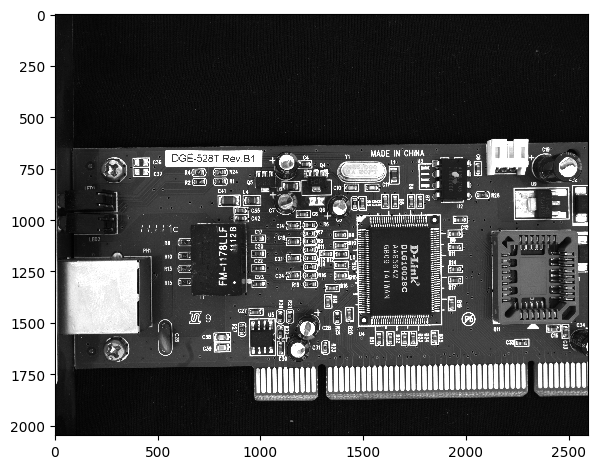

In [28]:
service = roslibpy.Service(
    ros, "/image_acquisition/capture", "open_aoi_interfaces/ServiceStatus"
)
request = roslibpy.ServiceRequest()
response = service.call(request, timeout=10)

print(response["error"])
print(response["error_description"])
imshow(pickle.loads(base64.decodebytes(response["image"]["data"].encode())))